# Web Traffic, Conversion & Payment Analysis

**Overview:** This notebook focuses on data preparation, feature engineering, and exploratory data analysis (EDA) for web traffic, conversion rates, and payment methods. The primary objective is to evaluate how user sessions convert into orders, understand the correlation between traffic and revenue, and analyze how different payment methods impact order cancellation rates.

## 1. Setup & Data Loading
In this section, we initialize our analytical environment, import required libraries, and ingest the pre-cleaned datasets for downstream processing.

### 1.1. Import Libraries & Environment Setup

In [13]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Ignore warning messages for cleaner notebook output
warnings.filterwarnings('ignore')

# Set plotting style and default figure size for consistency
%matplotlib inline
sns.set_theme(style="whitegrid")

### 1.2. Load Datasets
Loading the cleaned `.parquet` files from the processed dataset directory.

In [14]:
DATA_PATH = '../dataset/02_after_clean/'
print("Loading data...")

df_products = pd.read_parquet(DATA_PATH + 'products.parquet')
df_promotions = pd.read_parquet(DATA_PATH + 'promotions.parquet')

df_orders = pd.read_parquet(DATA_PATH + 'orders.parquet')
df_order_items = pd.read_parquet(DATA_PATH + 'order_items.parquet')

df_web_traffic = pd.read_parquet(DATA_PATH + 'web_traffic.parquet')

print("Load data successfully")

Loading data...
Load data successfully


## 2. Data Preprocessing & Feature Engineering

To conduct accurate behavioral and payment analysis, we must consolidate operational tables and engineer necessary order-level features (e.g., cancellation flags, clean installment formats).

### 2.1. Merging Datasets

In [15]:
df_master = pd.merge(df_products, df_order_items, on='product_id', how='left')
df_master = df_master.merge(df_promotions, on='promo_id', how='left')
df_master = df_master.merge(df_orders[['order_id', 'order_date','order_status', 'payment_method', 'payment_value', 'installments']], on='order_id', how='left')

df_master = df_master.merge(
    df_web_traffic,
    left_on='order_date',
    right_on='date',
    how='left'
)
df_master.drop(columns=['date'], inplace=True)
df_master['conversion_rate'] = 1 / df_master['sessions']

df_master = df_master.rename(columns={'order_date': 'Date'})
print("Kích thước bảng ban đầu:", df_master.shape)
df_master.head()

Kích thước bảng ban đầu: (715483, 35)


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,payment_method,payment_value,installments,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,conversion_rate
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451,5.0,...,credit_card,55918.35,1 period,10147.0,7857.0,33888.0,0.00572,121.9,social_media,0.000099
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898,8.0,...,bank_transfer,87350.00,12 periods,11908.0,9263.0,38118.0,0.00429,317.1,referral,0.000084
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268,6.0,...,credit_card,67107.30,3 periods,11908.0,9263.0,38118.0,0.00429,317.1,referral,0.000084
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907,2.0,...,cod,22209.44,1 period,10268.0,7696.0,50373.0,0.00496,208.1,organic_search,0.000097
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911,6.0,...,credit_card,66858.96,1 period,12673.0,9972.0,52366.0,0.00449,176.6,organic_search,0.000079


### 2.2. Feature Engineering & Data Cleaning
Extracting numeric installment values and aggregating cancellation statuses to the order level to maintain data consistency.

In [16]:
# Clean installments feature
df_master["installments"] = df_master["installments"].str.extract(r'(\d+)')
df_master["installments"] = pd.to_numeric(df_master["installments"], errors="coerce")
df_master["installments"] = df_master["installments"].fillna(1)

# Create raw cancellation flag
df_master["is_cancelled"] = (df_master["order_status"] == "cancelled").astype(int)

# Group to Order Level to ensure consistency
df_order_level = (
    df_master
    .groupby("order_id")
    .agg({
        "payment_method": "first",   # identical in one order
        "is_cancelled": "max"        # If there is a cancellation line, the entire order is cancelled.
    })
    .reset_index()
)

# Map cleaned cancellation flag back to master dataframe
df_master = df_master.merge(
    df_order_level[["order_id", "is_cancelled"]],
    on="order_id",
    how="left"
)

# Resolve column names
df_master["is_cancelled"] = df_master["is_cancelled_y"]
df_master = df_master.drop(columns=["is_cancelled_x", "is_cancelled_y"])

# Filter for valid orders
valid_orders = df_order_level["order_id"].unique()
df_master = df_master[df_master["order_id"].isin(valid_orders)]


df_master["payment_method"].value_counts(normalize=True)
df_master.drop_duplicates("order_id")["order_status"].value_counts()

print("Kích thước bảng sau khi làm sạch:", df_master.shape)

Kích thước bảng sau khi làm sạch: (714669, 36)


### 2.3. Feature Selection & Data Export
Reviewing the final structure of our dataset and exporting the prepared data for the EDA phase.

In [17]:
EXPORT_PATH = '../dataset/03_features/'
os.makedirs(EXPORT_PATH, exist_ok=True)
    
# Review dataset schemas and non-null counts
df_master.info()

# Export the processed dataframes
df_master.to_parquet(EXPORT_PATH + 'pay_traffic_order.parquet', index=False)

print("Data preparation complete.")

<class 'pandas.core.frame.DataFrame'>
Index: 714669 entries, 0 to 715482
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   product_id                714669 non-null  string        
 1   product_name              714669 non-null  string        
 2   category                  714669 non-null  category      
 3   segment                   714669 non-null  category      
 4   size                      714669 non-null  category      
 5   color                     714669 non-null  category      
 6   price                     714669 non-null  float64       
 7   cogs                      714669 non-null  float64       
 8   order_id                  714669 non-null  string        
 9   quantity                  714669 non-null  float64       
 10  unit_price                714669 non-null  float64       
 11  discount_amount           714669 non-null  float64       
 12  promo_i

## 3. Exploratory Data Analysis (EDA)
This section visually explores the relationship between web traffic and revenue generation, alongside a detailed breakdown of payment method behaviors and their corresponding cancellation risks.

### 3.1. Web Traffic & Conversion Rate Trends

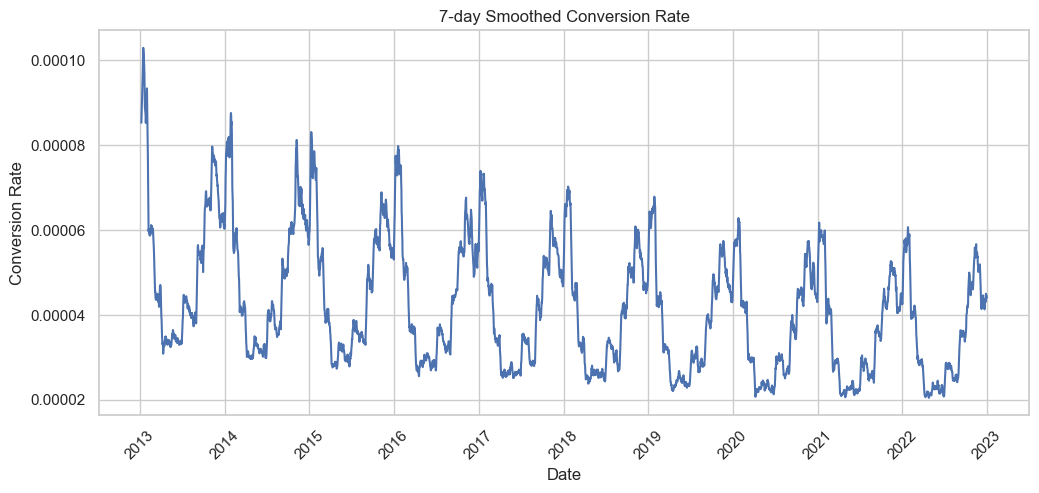

In [18]:
daily = df_master.groupby('Date').agg({
    'order_id': 'nunique',
    'sessions': 'sum'
}).reset_index()

daily['conversion_rate'] = daily['order_id'] / daily['sessions']
daily['conversion_rate_smooth'] = daily['conversion_rate'].rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily['Date'], daily['conversion_rate_smooth'])

plt.title("7-day Smoothed Conversion Rate")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)

plt.show()

#### **Insight:** 
The conversion rate exhibits a long-term downward trend despite traffic (sessions) remaining relatively stable. This indicates a potential decline in conversion efficiency over time, warning us that traffic is not translating into orders as effectively as it used to. This warrants a deeper investigation into the UI/UX user journey or pricing competitiveness.


### 3.2. Correlation: Sessions vs. Revenue

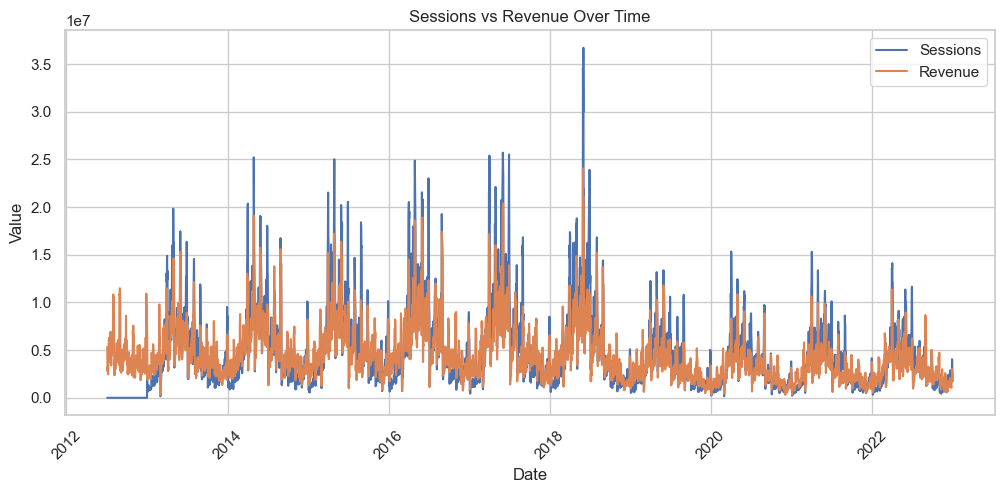

In [19]:
daily = df_master.groupby('Date').agg({
    'sessions': 'sum',
    'payment_value': 'sum'
}).reset_index()

plt.figure(figsize=(12,5))

plt.plot(daily['Date'], daily['sessions'], label='Sessions')
plt.plot(daily['Date'], daily['payment_value'], label='Revenue')

plt.title("Sessions vs Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend()

plt.show()

#### **Insight:** 
There is a strong positive correlation between traffic (sessions) and revenue. As sessions increase, revenue scales almost in tandem, proving that driving top-of-funnel traffic directly impacts the bottom line. Furthermore, distinct seasonality is visible, with cyclical peaks likely aligning with major annual shopping events (e.g., Black Friday, holidays).



### 3.3. Payment Method Adoption & Distribution

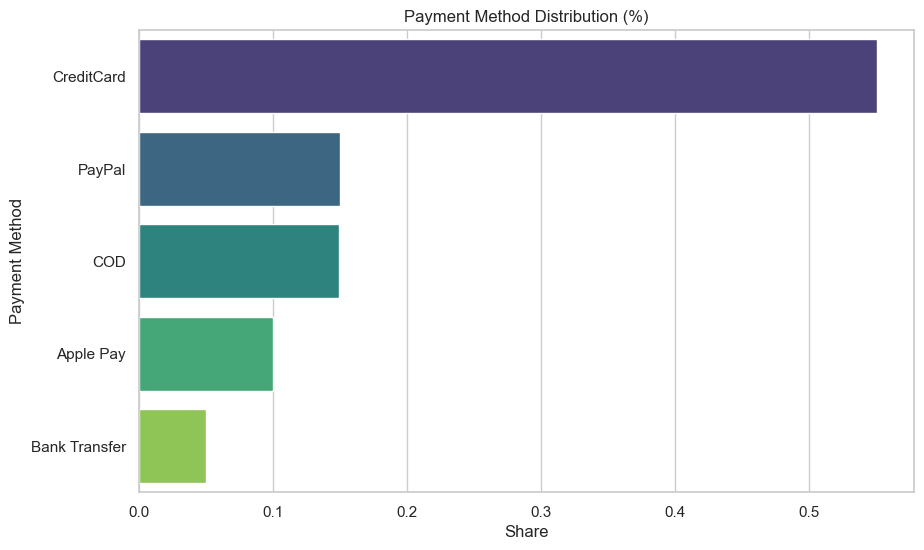

In [20]:
payment_dist = {
    "CreditCard": 0.550823,
    "PayPal": 0.149963,
    "COD": 0.149442,
    "Apple Pay": 0.100106,
    "Bank Transfer": 0.049666
}

pay_data = pd.DataFrame(list(payment_dist.items()), columns=["payment_method", "share"])
pay_data = pay_data.sort_values("share", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=pay_data,
    x="share",
    y="payment_method",
    hue="payment_method",
    palette="viridis",
    legend=False
)

plt.title("Payment Method Distribution (%)")
plt.xlabel("Share")
plt.ylabel("Payment Method")
plt.show()

### 3.4. Cancellation Risk by Payment Method

In [21]:
cancel_rate = (
    df_order_level
    .groupby("payment_method", observed=True)["is_cancelled"]
    .mean()
    .reset_index()
)
cancel_rate = cancel_rate.sort_values(
    by="is_cancelled",
    ascending=False
)
cancel_rate["is_cancelled"] *= 100

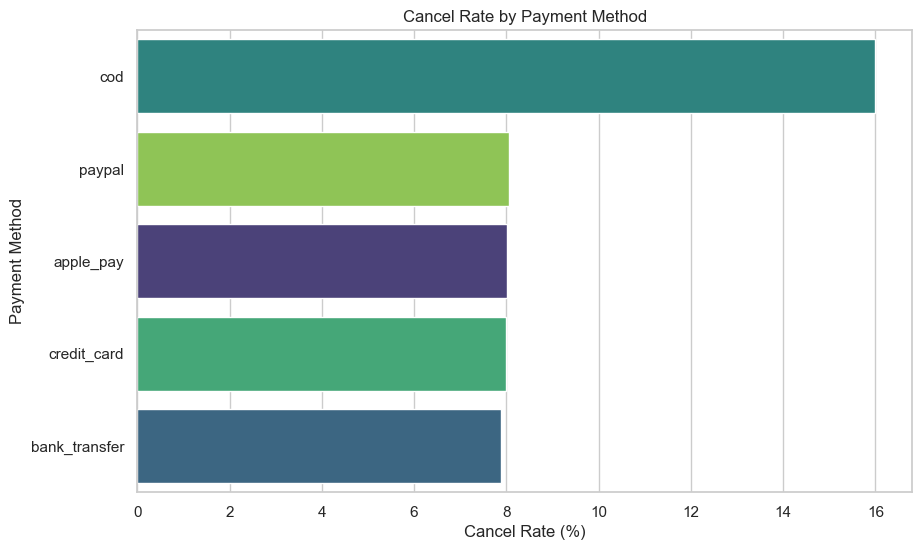

In [22]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(
    data=cancel_rate,
    x="is_cancelled",
    y="payment_method",
    hue="payment_method",
    palette="viridis",
    legend=False,
    order=cancel_rate["payment_method"]
)

plt.title("Cancel Rate by Payment Method")
plt.xlabel("Cancel Rate (%)")
plt.ylabel("Payment Method")
plt.show()

#### **Insight:** 
Payment methods significantly impact order completion reliability. Cash on Delivery (COD) experiences the highest cancellation rate, largely due to the lack of upfront financial commitment from the buyer. Conversely, digital payments (Credit Card, Apple Pay) show substantially lower cancellation rates. Promoting digital transactions can effectively decrease order fallout and improve overall revenue quality.



### 3.5. Revenue Contribution by Payment Method

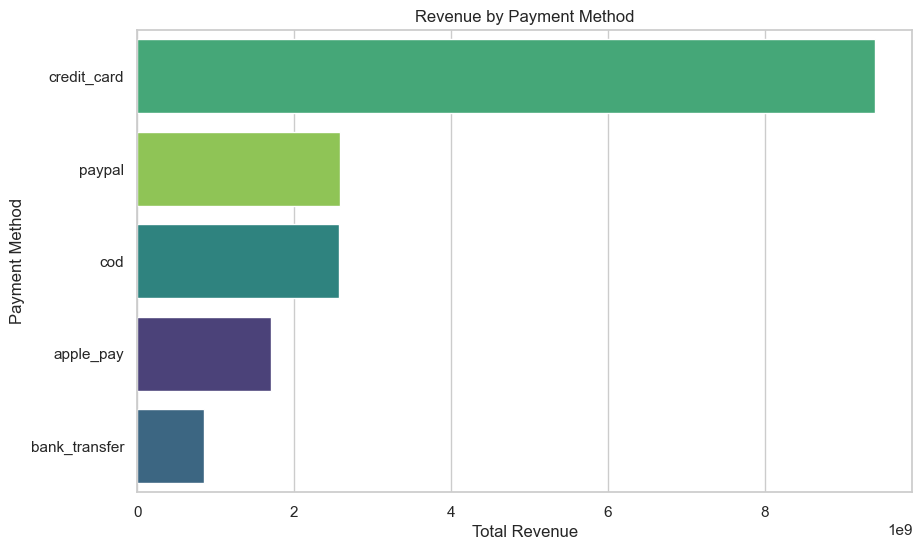

In [23]:
rev_by_pay = (
    df_master
    .groupby("payment_method", observed=False)["payment_value"]
    .agg(["sum", "mean", "count"])
    .reset_index()
)
rev_by_pay = rev_by_pay.sort_values(
    by="sum",
    ascending=False
)
plt.figure(figsize=(10,6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

sns.barplot(
    data=rev_by_pay,
    x="sum",
    y="payment_method",
    hue="payment_method",
    palette="viridis",
    legend=False,
    order=rev_by_pay["payment_method"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Total Revenue")
plt.ylabel("Payment Method")

plt.show()

#### **Insight:** 
Credit cards dominate revenue by a large margin, showcasing a strong customer preference for convenient digital payments and likely correlating with higher cart values. PayPal and COD contribute at a moderate, similar level, while Apple Pay is less adopted and bank transfer is minimal, indicating lower efficiency and user preference for these latter options.